# 05 - Modelos Boosting: Superando los baselines con CatBoost

## Objetivo

Este notebook entrena modelos de **gradient boosting (CatBoost)** sobre las features
construidas en los notebooks anteriores. Usa **Optuna TPE** con **3 fases**,
**20 hiperparámetros** (CPU, todos desbloqueados), **warm-start**, **pruning** y
**ensemble top-5** para encontrar y combinar los mejores modelos posibles.
Los estudios se persisten en SQLite para re-ejecución instantánea.

**Dual target**: `price` (EUR/mes) y `price_m2` (EUR/m²).

### Esquemas de validación cruzada
| Esquema | Qué mide | Implementación |
|---------|----------|----------------|
| **Normal** | Rendimiento general | KFold(5, shuffle) |
| **Group** | Generalización entre distritos | GroupKFold(5) por distrito |
| **Spatial** | Generalización geográfica | GroupKFold por geohash-6 |
| **Temporal** | Estabilidad en el tiempo | TimeSeriesSplit(5, gap=7d) |

### Optimización de hiperparámetros (Optuna)
- **2000 trials** (price) / **200 trials** (price_m2) en 3 fases:
  1. **TPE** — exploración bayesiana global
  2. **TPE multivariante+grupo** — aprende correlaciones entre params
  3. **TPE refinamiento** — concentra búsqueda con priors
- **Warm-start**: 3 configs conocidas inyectadas como primeros trials
- **20 hiperparámetros**: iterations, depth, lr, l2, bagging_temp, random_strength,
  min_data_in_leaf, border_count, od_wait, subsample, grow_policy, max_leaves,
  bootstrap_type (Bayesian/Bernoulli/MVS), boosting_type (Plain/Ordered),
  leaf_estimation_iterations, model_size_reg, rsm, sampling_frequency
- **Ensemble top-5**: promedia predicciones de las 5 mejores configs
- **MedianPruner**: corta trials malos a mitad de CV
- **Persistencia SQLite**: re-ejecutar usa resultados cacheados instantáneamente

### Feature Selection (post-training)
Consenso de 3 métodos: SelectKBest + SHAP + Permutation noise probe.
Prueba 3 umbrales (leve/moderado/agresivo) y adopta solo si mejora MAE.

In [7]:
from __future__ import annotations
from pathlib import Path
import sys
import json
import hashlib
import re

import numpy as np
import pandas as pd

# --- Base setup y reproducibilidad ---
SEED = 100432070
np.random.seed(SEED)

def get_repo_root() -> Path:
    """Return repo root by walking parents looking for .git or pyproject.toml."""
    current = Path.cwd().resolve()
    for parent in [current] + list(current.parents):
        if (parent / ".git").exists() or (parent / "pyproject.toml").exists():
            return parent
    return current

ROOT = get_repo_root()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.utils import DataFrameImputer, eval_regression, make_boosting_pipeline, get_feature_cols, TARGET_COLS, DERIVED_FROM_TARGET, ID_COLS

In [8]:
from sklearn.model_selection import KFold, GroupKFold, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from src.utils import spatial_group, eval_regression, make_boosting_pipeline, get_feature_cols
import importlib.util
import joblib
import subprocess
import datetime
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Cargar features_master (core + enrichment + VUT) ---
features_path = ROOT / "artifacts" / "features_master.parquet"
if features_path.exists():
    df = pd.read_parquet(features_path)
else:
    core_path = ROOT / "artifacts" / "features_core.parquet"
    if core_path.exists():
        df = pd.read_parquet(core_path)
    else:
        df = pd.read_csv(ROOT / "artifacts" / "features_core.csv.gz")

processed_path = ROOT / "artifacts" / "processed_rent.parquet"
if processed_path.exists():
    raw_df = pd.read_parquet(processed_path)
else:
    raw_df = pd.read_csv(ROOT / "artifacts" / "processed_rent.csv.gz")

print(f"Dataset cargado: {len(df)} filas, {len(df.columns)} columnas")

# --- Split fijo ---
split = np.load(ROOT / "artifacts" / "splits" / "holdout_indices.npz")
train_idx, test_idx = split["train_idx"], split["test_idx"]

# --- Seleccion de features (explicita + regex safety belt) ---
feature_cols = get_feature_cols(df, numeric_only=True)
print(f"Features seleccionadas: {len(feature_cols)}")

# --- Helpers para zonas y CV ---
zone_keys = ("distrito", "barrio", "district", "subdistrict")

def _find_zone_col(columns):
    for col in columns:
        if any(k in col.lower() for k in zone_keys):
            return col
    return None

def _group_stats(groups):
    sizes = pd.Series(groups).value_counts()
    return {
        "n_groups": int(sizes.shape[0]),
        "mean_size": float(sizes.mean()),
        "median_size": float(sizes.median()),
        "min_size": int(sizes.min()),
        "max_size": int(sizes.max()),
    }

# --- Modelo boosting ---
build_model, _param_distributions, _boosting_engine = make_boosting_pipeline(seed=SEED)
print(f"Motor boosting: {_boosting_engine}")

# --- Git SHA para metadata ---
_git_sha = "unknown"
try:
    _git_sha = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=str(ROOT)).decode().strip()
except Exception:
    pass

# ===================================================================
# DUAL TARGET: entrenar para price y price_m2
# ===================================================================
TARGETS = {"price": "price", "price_m2": "price_m2"}
all_cv_metrics = []
all_holdout_metrics = []
dual_model_artifact = {"metadata": {"timestamp": datetime.datetime.now().isoformat(), "git_sha": _git_sha, "boosting_engine": _boosting_engine}}

(ROOT / "models").mkdir(parents=True, exist_ok=True)

# ===================================================================
# OPTUNA CONFIG — Optimización máxima (CPU, todos los params desbloqueados)
# ===================================================================
OPTUNA_N_TRIALS = 200    # Total: 150 TPE + 30 MV + 20 TPE refinamiento
_N_TPE = 150             # Fase 1: exploración bayesiana global
_N_MV = 30               # Fase 2: TPE multivariante (correlaciones)
_N_TPE2 = 20             # Fase 3: TPE refinamiento final con prior del mejor
_optuna_db = ROOT / "models" / "optuna_studies.db"
_storage = f"sqlite:///{_optuna_db.as_posix()}"
_STUDY_VERSION = "v5"    # CPU + 20 params + 2000 trials + 3 fases + warm-start

for target_name, target_col in TARGETS.items():
    if target_col not in df.columns:
        print(f"\nSKIP target={target_name}: columna {target_col} no encontrada")
        continue

    print(f"\n{'='*60}")
    print(f"TARGET: {target_name} ({target_col})")
    print(f"{'='*60}")

    y = df[target_col]

    # Train/test split
    y_train_raw = y.loc[train_idx].reset_index(drop=True)
    y_test_raw = y.loc[test_idx].reset_index(drop=True)
    train_mask = np.isfinite(y_train_raw.replace([np.inf, -np.inf], np.nan))
    test_mask = np.isfinite(y_test_raw.replace([np.inf, -np.inf], np.nan))
    y_train = y_train_raw.loc[train_mask].reset_index(drop=True)
    y_test = y_test_raw.loc[test_mask].reset_index(drop=True)

    # Column selection on TRAIN only
    df_train_full = df.loc[train_idx, feature_cols].reset_index(drop=True).loc[train_mask].reset_index(drop=True)
    all_missing = df_train_full.columns[df_train_full.notna().sum() == 0]
    active_cols = [c for c in feature_cols if c not in all_missing]
    if all_missing.any():
        print(f"  Columnas eliminadas (vacias en train): {list(all_missing)}")

    X_train = df.loc[train_idx, active_cols].reset_index(drop=True).loc[train_mask].reset_index(drop=True)
    X_test = df.loc[test_idx, active_cols].reset_index(drop=True).loc[test_mask].reset_index(drop=True)
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)

    if X_train.empty:
        print(f"  SKIP: sin muestras tras filtrar target")
        continue

    print(f"  Features activas: {len(active_cols)}, Train: {len(X_train)}, Test: {len(X_test)}")

    # --- CV normal (5-fold) con params por defecto ---
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    mae_scores = []
    for tr_idx_cv, val_idx_cv in cv.split(X_train):
        m = build_model()
        m.fit(X_train.iloc[tr_idx_cv], y_train.iloc[tr_idx_cv])
        preds = m.predict(X_train.iloc[val_idx_cv])
        mae_scores.append(mean_absolute_error(y_train.iloc[val_idx_cv], preds))
    print(f"  CV normal MAE (default): {np.mean(mae_scores):.2f} (+/- {np.std(mae_scores):.2f})")

    # =================================================================
    # OPTUNA — 1000 trials, GPU, MedianPruner, 18 hiperparámetros
    # =================================================================
    # Fase 1: TPE (700 trials) — exploración bayesiana global
    # Fase 2: CMA-ES (300 trials) — refinamiento local alrededor del mejor
    # MedianPruner: corta trials peores que la mediana tras fold 2
    _study_name = f"catboost_{_STUDY_VERSION}_{target_name}"
    _pruner = optuna.pruners.MedianPruner(
        n_startup_trials=15,   # No podar hasta tener 15 trials completos
        n_warmup_steps=1,      # No podar antes de fold 2
    )

    # Cargar estudio existente o crear uno nuevo
    try:
        study = optuna.load_study(
            study_name=_study_name, storage=_storage,
            pruner=_pruner,
        )
        _existing = len(study.trials)
        print(f"  Optuna: estudio '{_study_name}' cargado ({_existing} trials previos)")
    except KeyError:
        study = optuna.create_study(
            study_name=_study_name, storage=_storage,
            direction="minimize",
            sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=40),
            pruner=_pruner,
        )
        _existing = 0
        print(f"  Optuna: nuevo estudio '{_study_name}'")

        # Warm-start: inyectar params conocidos para no perder trials iniciales
        study.enqueue_trial({
            "iterations": 300, "depth": 8, "learning_rate": 0.1,
            "l2_leaf_reg": 10.0, "random_strength": 1.0,
            "min_data_in_leaf": 1, "border_count": 254,
            "od_wait": 50, "model_size_reg": 0.0,
            "leaf_estimation_iterations": 1, "rsm": 1.0,
            "grow_policy": "SymmetricTree", "boosting_type": "Plain",
            "bootstrap_type": "Bayesian", "bagging_temperature": 1.0,
        })
        study.enqueue_trial({
            "iterations": 1000, "depth": 6, "learning_rate": 0.03,
            "l2_leaf_reg": 3.0, "random_strength": 5.0,
            "min_data_in_leaf": 10, "border_count": 128,
            "od_wait": 80, "model_size_reg": 1.0,
            "leaf_estimation_iterations": 3, "rsm": 0.8,
            "grow_policy": "SymmetricTree", "boosting_type": "Ordered",
            "bootstrap_type": "MVS", "subsample": 0.8,
            "sampling_frequency": "PerTree",
        })
        study.enqueue_trial({
            "iterations": 2000, "depth": 10, "learning_rate": 0.01,
            "l2_leaf_reg": 1.0, "random_strength": 10.0,
            "min_data_in_leaf": 5, "border_count": 200,
            "od_wait": 100, "model_size_reg": 3.0,
            "leaf_estimation_iterations": 5, "rsm": 0.7,
            "grow_policy": "Lossguide", "max_leaves": 64,
            "bootstrap_type": "Bernoulli", "subsample": 0.7,
            "sampling_frequency": "PerTree",
        })
        print(f"  Warm-start: 3 configs conocidas inyectadas")

    _cv_optuna = KFold(n_splits=5, shuffle=True, random_state=SEED)
    _cv_splits = list(_cv_optuna.split(X_train))  # Pre-compute splits

    def _optuna_objective(trial):
        # --- 20 hiperparámetros (CPU, TODO desbloqueado) ---
        try:
            return _optuna_objective_inner(trial)
        except optuna.TrialPruned:
            raise
        except Exception:
            return float("inf")  # Config inválida — penalizar sin crashear

    def _optuna_objective_inner(trial):
        params = {
            "model__iterations": trial.suggest_int("iterations", 300, 5000),
            "model__depth": trial.suggest_int("depth", 3, 12),
            "model__learning_rate": trial.suggest_float("learning_rate", 0.001, 0.3, log=True),
            "model__l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 0.001, 100.0, log=True),
            "model__random_strength": trial.suggest_float("random_strength", 0.0, 20.0),
            "model__min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 200),
            "model__border_count": trial.suggest_int("border_count", 32, 255),
            "model__od_type": "Iter",
            "model__od_wait": trial.suggest_int("od_wait", 20, 150),
            "model__model_size_reg": trial.suggest_float("model_size_reg", 0.0, 10.0),
            "model__leaf_estimation_method": "Gradient",  # MAE solo soporta Gradient
            "model__leaf_estimation_iterations": trial.suggest_int(
                "leaf_estimation_iterations", 1, 15),
            "model__rsm": trial.suggest_float("rsm", 0.5, 1.0),
        }

        # Grow policy + max_leaves condicional (primero, porque condiciona otros params)
        grow = trial.suggest_categorical("grow_policy", ["SymmetricTree", "Lossguide", "Depthwise"])
        params["model__grow_policy"] = grow
        if grow == "Lossguide":
            params["model__max_leaves"] = trial.suggest_int("max_leaves", 16, 128)

        # Boosting type: Ordered solo compatible con SymmetricTree
        if grow == "SymmetricTree":
            boosting = trial.suggest_categorical("boosting_type", ["Plain", "Ordered"])
        else:
            boosting = "Plain"  # Lossguide/Depthwise no soportan Ordered
        params["model__boosting_type"] = boosting

        # Bootstrap type (CPU: Bayesian, Bernoulli, MVS) — params condicionales
        bootstrap = trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli", "MVS"])
        params["model__bootstrap_type"] = bootstrap
        if bootstrap == "Bayesian":
            params["model__bagging_temperature"] = trial.suggest_float("bagging_temperature", 0.0, 20.0)
        else:  # Bernoulli o MVS
            params["model__subsample"] = trial.suggest_float("subsample", 0.5, 1.0)
            # PerTreeLevel no compatible con Lossguide
            if grow == "Lossguide":
                params["model__sampling_frequency"] = "PerTree"
            else:
                params["model__sampling_frequency"] = trial.suggest_categorical(
                    "sampling_frequency", ["PerTree", "PerTreeLevel"])

        # --- CV manual con pruning por fold ---
        scores = []
        for fold_i, (tr_i, val_i) in enumerate(_cv_splits):
            m = build_model()
            m.set_params(**params)
            m.fit(X_train.iloc[tr_i], y_train.iloc[tr_i])
            pred = m.predict(X_train.iloc[val_i])
            fold_mae = mean_absolute_error(y_train.iloc[val_i], pred)
            scores.append(fold_mae)

            # Reportar MAE acumulada — MedianPruner decide si cortar
            trial.report(np.mean(scores), fold_i)
            if trial.should_prune():
                raise optuna.TrialPruned()

        return np.mean(scores)

    # --- Fase 1: TPE (exploración global) ---
    _remaining_tpe = max(0, _N_TPE - _existing)
    if _remaining_tpe > 0:
        print(f"  Fase 1/3: TPE — {_remaining_tpe} trials (de {_N_TPE})...")
        study.sampler = optuna.samplers.TPESampler(seed=SEED, n_startup_trials=40)
        study.optimize(_optuna_objective, n_trials=_remaining_tpe, show_progress_bar=True, catch=(Exception,))
        print(f"  Fase 1 completada. Mejor MAE: {study.best_value:.2f}")

    # --- Fase 2: TPE multivariante (aprende correlaciones entre params) ---
    _done_after_tpe = len(study.trials)
    _remaining_mv = max(0, _N_TPE + _N_MV - _done_after_tpe)
    if _remaining_mv > 0:
        print(f"  Fase 2/3: TPE multivariante — {_remaining_mv} trials (correlaciones)...")
        study.sampler = optuna.samplers.TPESampler(
            seed=SEED + 1, n_startup_trials=10,
            multivariate=True, group=True,
        )
        study.optimize(_optuna_objective, n_trials=_remaining_mv, show_progress_bar=True, catch=(Exception,))
        print(f"  Fase 2 completada. Mejor MAE: {study.best_value:.2f}")

    # --- Fase 3: TPE refinamiento final (concentrado alrededor del mejor) ---
    _done_after_mv = len(study.trials)
    _remaining_tpe2 = max(0, OPTUNA_N_TRIALS - _done_after_mv)
    if _remaining_tpe2 > 0:
        print(f"  Fase 3/3: TPE refinamiento — {_remaining_tpe2} trials...")
        study.sampler = optuna.samplers.TPESampler(
            seed=SEED + 1, n_startup_trials=10,
            consider_prior=True, prior_weight=1.0,
            multivariate=True, group=True,
        )
        study.optimize(_optuna_objective, n_trials=_remaining_tpe2, show_progress_bar=True, catch=(Exception,))
        print(f"  Fase 3 completada. Mejor MAE: {study.best_value:.2f}")

    if _remaining_tpe == 0 and _remaining_mv == 0 and _remaining_tpe2 == 0:
        print(f"  Ya completados {_existing}/{OPTUNA_N_TRIALS} trials. Usando mejores params guardados.")

    best_trial = study.best_trial
    _completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    _n_pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
    _n_failed = len([t for t in study.trials if t.state == optuna.trial.TrialState.FAIL])
    print(f"\n  === MEJOR TRIAL #{best_trial.number} ===")
    print(f"  MAE CV: {best_trial.value:.2f}")
    print(f"  Trials: {len(study.trials)} total, {len(_completed)} completos, {_n_pruned} podados, {_n_failed} fallidos")

    def _clean_trial_params(trial):
        """Limpia params de un trial para set_params()."""
        bp = {f"model__{k}": v for k, v in trial.params.items()}
        if trial.params.get("bootstrap_type") == "Bayesian":
            bp.pop("model__subsample", None)
            bp.pop("model__sampling_frequency", None)
        else:
            bp.pop("model__bagging_temperature", None)
        if trial.params.get("grow_policy") != "Lossguide":
            bp.pop("model__max_leaves", None)
        if trial.params.get("grow_policy") != "SymmetricTree":
            bp.pop("model__boosting_type", None)
        bp["model__od_type"] = "Iter"
        return bp

    best_params = _clean_trial_params(best_trial)
    best_cv_score = best_trial.value
    print(f"  Params: {best_trial.params}")

    # --- Ensemble top-5: promediar predicciones de los 5 mejores configs ---
    _TOP_N = min(5, len(_completed))
    _top_trials = sorted(_completed, key=lambda t: t.value)[:_TOP_N]
    print(f"\n  Top-{_TOP_N} trials (MAE CV):")
    for i, t in enumerate(_top_trials):
        print(f"    #{i+1}: Trial {t.number} — MAE={t.value:.2f}")

    _ensemble_models = []
    for t in _top_trials:
        tp = _clean_trial_params(t)
        m = build_model()
        m.set_params(**tp)
        _ensemble_models.append(m)

    def build_tuned_model():
        m = build_model()
        m.set_params(**best_params)
        return m

    best_model = build_tuned_model()

    # --- GroupCV por distrito ---
    zone_col = _find_zone_col(df.columns)
    group_scores = []
    if zone_col:
        groups = df.loc[train_idx, zone_col].reset_index(drop=True).loc[train_mask].reset_index(drop=True).fillna("unknown")
        if groups.nunique() >= 5:
            gkf = GroupKFold(n_splits=5)
            for tr_i, val_i in gkf.split(X_train, y_train, groups):
                m = build_tuned_model()
                m.fit(X_train.iloc[tr_i], y_train.iloc[tr_i])
                preds = m.predict(X_train.iloc[val_i])
                group_scores.append(mean_absolute_error(y_train.iloc[val_i], preds))

    # --- Spatial CV por geohash ---
    lat_col = next((c for c in df.columns if "lat" in c.lower()), None)
    lon_col = next((c for c in df.columns if "lon" in c.lower() or "lng" in c.lower()), None)
    spatial_scores_6 = []

    if lat_col and lon_col:
        train_geo = df.loc[train_idx].reset_index(drop=True).loc[train_mask].reset_index(drop=True)
        geo_groups = spatial_group(train_geo, lat_col, lon_col, precision=6)
        geo_groups = pd.Series(geo_groups).fillna("unknown")
        n_groups = geo_groups.nunique()
        if n_groups >= 3:
            n_splits = min(5, n_groups)
            sgkf = GroupKFold(n_splits=n_splits)
            for tr_i, val_i in sgkf.split(X_train, y_train, geo_groups):
                m = build_tuned_model()
                m.fit(X_train.iloc[tr_i], y_train.iloc[tr_i])
                preds = m.predict(X_train.iloc[val_i])
                spatial_scores_6.append(mean_absolute_error(y_train.iloc[val_i], preds))

    # --- Temporal CV ---
    temporal_scores = []
    GAP_DAYS = 7
    ASSUMED_SNAPSHOT_YEAR = 2025
    time_cv_gap = 1
    date_keys = ("date", "fecha", "update", "scrape", "publica")
    date_cols = [c for c in raw_df.columns if any(k in c.lower() for k in date_keys)]
    if date_cols:
        date_col = date_cols[0]
        date_series = raw_df[date_col].dropna().astype(str).str.strip()
        if not date_series.empty:
            has_year = date_series.str.contains(r"\d{4}")
            day_month_only = date_series.str.match(r"^\d{1,2}\s+[A-Za-z]+$")
            if day_month_only.all() and not has_year.any():
                split_cfg_path = ROOT / "artifacts" / "splits" / "split_config.json"
                assumed_year = ASSUMED_SNAPSHOT_YEAR
                if split_cfg_path.exists():
                    try:
                        split_cfg = json.loads(split_cfg_path.read_text(encoding="utf-8"))
                        assumed_year = int(split_cfg.get("assumed_year") or ASSUMED_SNAPSHOT_YEAR)
                    except Exception:
                        pass
                train_meta = raw_df.loc[train_idx].reset_index(drop=True).loc[train_mask].reset_index(drop=True)
                train_meta[date_col] = pd.to_datetime(
                    train_meta[date_col].astype(str).str.strip() + f" {assumed_year}",
                    errors="coerce", format="%d %B %Y",
                )
            else:
                train_meta = raw_df.loc[train_idx].reset_index(drop=True).loc[train_mask].reset_index(drop=True)
                train_meta[date_col] = pd.to_datetime(train_meta[date_col], errors="coerce", format="mixed")
            valid_date_mask = train_meta[date_col].notna()
            if valid_date_mask.sum() >= 20:
                avg_per_day = train_meta.loc[valid_date_mask, date_col].dt.date.value_counts().mean()
                time_cv_gap = max(1, int(round(avg_per_day * GAP_DAYS)))
                X_time = X_train.loc[valid_date_mask].reset_index(drop=True)
                y_time = y_train.loc[valid_date_mask].reset_index(drop=True)
                dates = train_meta.loc[valid_date_mask, date_col].reset_index(drop=True)
                order = dates.sort_values().index
                X_time = X_time.loc[order].reset_index(drop=True)
                y_time = y_time.loc[order].reset_index(drop=True)
                tscv = TimeSeriesSplit(n_splits=5, gap=time_cv_gap)
                for tr_i, val_i in tscv.split(X_time):
                    m = build_tuned_model()
                    m.fit(X_time.iloc[tr_i], y_time.iloc[tr_i])
                    preds = m.predict(X_time.iloc[val_i])
                    temporal_scores.append(mean_absolute_error(y_time.iloc[val_i], preds))

    # --- Entrenar modelo final en todo el train ---
    best_model.fit(X_train, y_train)

    # --- Entrenar ensemble top-5 ---
    for em in _ensemble_models:
        em.fit(X_train, y_train)
    _ensemble_preds_test = np.mean([em.predict(X_test) for em in _ensemble_models], axis=0)

    # --- Evaluacion holdout: single best vs ensemble ---
    _single_preds = best_model.predict(X_test)
    _single_mae = mean_absolute_error(y_test, _single_preds)
    _ensemble_mae = mean_absolute_error(y_test, _ensemble_preds_test)
    print(f"\n  Single best MAE: {_single_mae:.2f}")
    print(f"  Ensemble top-{_TOP_N} MAE: {_ensemble_mae:.2f}")

    # Usar ensemble si es mejor, si no usar single best
    if _ensemble_mae < _single_mae:
        holdout_preds = _ensemble_preds_test
        print(f"  >>> Ensemble GANA por {_single_mae - _ensemble_mae:.2f} EUR — usando ensemble")
        _using_ensemble = True
    else:
        holdout_preds = _single_preds
        print(f"  >>> Single best gana — usando modelo individual")
        _using_ensemble = False

    segments_holdout = {}
    cat_cols = [c for c in df.columns if any(k in c.lower() for k in ["distrito", "barrio", "district", "subdistrict"])]
    if cat_cols:
        group_col = cat_cols[0]
        test_groups = df.loc[test_idx, group_col].reset_index(drop=True).loc[test_mask].reset_index(drop=True)
        top_groups = test_groups.value_counts().head(8).index
        for grp in top_groups:
            segments_holdout[f"{group_col}_{grp}"] = np.where(test_groups == grp)[0]

    holdout_metrics = eval_regression(y_test, holdout_preds, segments=segments_holdout)
    print(f"\n  HOLDOUT MAE: {holdout_metrics['mae']:.2f}, R2: {holdout_metrics['r2']:.3f}")

    # --- Guardar metricas CV ---
    all_cv_metrics.append({
        "target": target_name,
        "cv_mae": np.mean(mae_scores),
        "tuned_cv_mae": best_cv_score,
        "group_cv_mae": np.mean(group_scores) if group_scores else None,
        "spatial_cv_mae_6": np.mean(spatial_scores_6) if spatial_scores_6 else None,
        "temporal_cv_mae": np.mean(temporal_scores) if temporal_scores else None,
    })

    holdout_row = {"target": target_name}
    holdout_row.update(holdout_metrics)
    all_holdout_metrics.append(holdout_row)

    # --- Guardar en artefacto dual ---
    best_params_serializable = {k: (v.item() if hasattr(v, "item") else v) for k, v in best_params.items()}
    dual_model_artifact[target_name] = {
        "model": best_model,
        "ensemble_models": _ensemble_models if _using_ensemble else None,
        "using_ensemble": _using_ensemble,
        "feature_names": list(X_train.columns),
        "best_params": best_params_serializable,
        "cv_mae": float(best_cv_score),
        "holdout_mae": float(holdout_metrics["mae"]),
        "holdout_r2": float(holdout_metrics["r2"]),
        "optuna_n_trials": len(study.trials),
        "optuna_n_pruned": _n_pruned,
        "ensemble_mae": float(_ensemble_mae),
        "single_mae": float(_single_mae),
    }

    # --- Guardar best_model.joblib (legacy, solo price) ---
    if target_name == "price":
        legacy_artifact = {
            "model": best_model,
            "feature_names": list(X_train.columns),
            "timestamp": datetime.datetime.now().isoformat(),
            "git_sha": _git_sha,
            "best_params": best_params_serializable,
            "boosting_engine": _boosting_engine,
            "cv_mae": float(best_cv_score),
            "holdout_mae": float(holdout_metrics["mae"]),
            "holdout_r2": float(holdout_metrics["r2"]),
        }
        joblib.dump(legacy_artifact, ROOT / "models" / "best_model.joblib")
        print(f"  Legacy model guardado: models/best_model.joblib")

# --- Guardar artefacto dual (ambos targets) ---
joblib.dump(dual_model_artifact, ROOT / "models" / "best_models.joblib")
print(f"\nDual model guardado: models/best_models.joblib")

# --- Guardar metricas ---
cv_df = pd.DataFrame(all_cv_metrics)
cv_df.to_csv(ROOT / "reports" / "boosting_metrics.csv", index=False)

holdout_df = pd.DataFrame(all_holdout_metrics)
holdout_df.to_csv(ROOT / "reports" / "holdout_metrics.csv", index=False)

# --- Guardar hiperparametros del modelo principal (price) ---
if "price" in dual_model_artifact:
    (ROOT / "reports" / "best_hyperparams.json").write_text(
        json.dumps(dual_model_artifact["price"]["best_params"], indent=2, ensure_ascii=False),
        encoding="utf-8",
    )

print(f"\nMetricas CV guardadas: {len(cv_df)} targets")
print(f"Metricas holdout guardadas: {len(holdout_df)} targets")
cv_df

Dataset cargado: 8797 filas, 70 columnas
Features seleccionadas: 49
Motor boosting: catboost

TARGET: price (price)
  Features activas: 49, Train: 6431, Test: 1772
  CV normal MAE (default): 400.22 (+/- 15.43)
  Optuna: estudio 'catboost_v5_price' cargado (2000 trials previos)
  Ya completados 2000/200 trials. Usando mejores params guardados.

  === MEJOR TRIAL #898 ===
  MAE CV: 391.48
  Trials: 2000 total, 760 completos, 1238 podados, 2 fallidos
  Params: {'iterations': 4997, 'depth': 8, 'learning_rate': 0.29915045507974913, 'l2_leaf_reg': 0.015088745786191366, 'random_strength': 14.983514265381537, 'min_data_in_leaf': 17, 'border_count': 56, 'od_wait': 73, 'model_size_reg': 8.254333438517223, 'leaf_estimation_iterations': 15, 'rsm': 0.6101741207485138, 'grow_policy': 'Depthwise', 'bootstrap_type': 'MVS', 'subsample': 0.9686170013692436, 'sampling_frequency': 'PerTree'}

  Top-5 trials (MAE CV):
    #1: Trial 898 — MAE=391.48
    #2: Trial 1166 — MAE=391.57
    #3: Trial 935 — MAE=39

,target,cv_mae,tuned_cv_mae,group_cv_mae,spatial_cv_mae_6,temporal_cv_mae
0,price,400.216477,391.476048,603.337565,566.266454,494.114779
1,price_m2,4.107727,3.869067,5.257403,4.763400,4.430408


In [9]:
# Resumen de metricas holdout (ya calculadas en celda anterior)
holdout_df

,target,mae,rmse,r2,mae_district_Centro,rmse_district_Centro,r2_district_Centro,mae_district_Chamberi,rmse_district_Chamberi,r2_district_Chamberi,...,r2_district_Chamartin,mae_district_Fuencarral,rmse_district_Fuencarral,r2_district_Fuencarral,mae_district_Hortaleza,rmse_district_Hortaleza,r2_district_Hortaleza,mae_district_Retiro,rmse_district_Retiro,r2_district_Retiro
0,price,301.309254,587.776172,0.803811,385.435922,609.759052,0.771683,452.225872,940.916399,0.750662,...,0.858285,218.530179,401.413991,0.673557,263.132190,366.000469,0.930895,355.227399,704.257905,0.597249
1,price_m2,3.163214,5.172443,0.586840,5.439619,7.815560,0.315881,4.017104,5.442459,0.440843,...,0.334327,1.681930,2.443968,0.659761,2.445265,3.441115,0.217498,3.379299,5.094864,0.291992


### Visualizaciones de validacion
- Boxplot MAE por esquema de CV.
- Histograma de residuals en holdout.


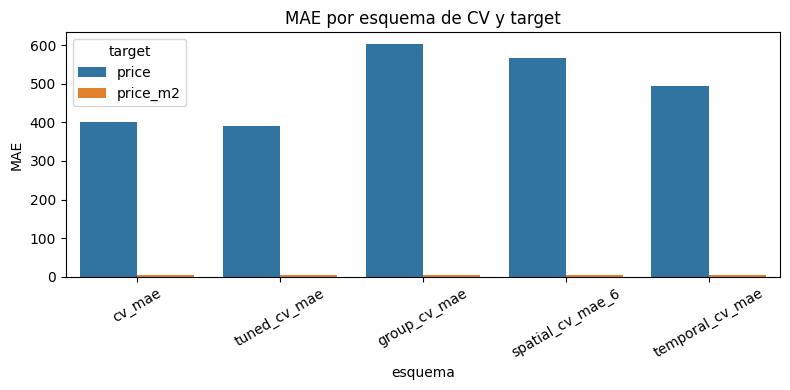

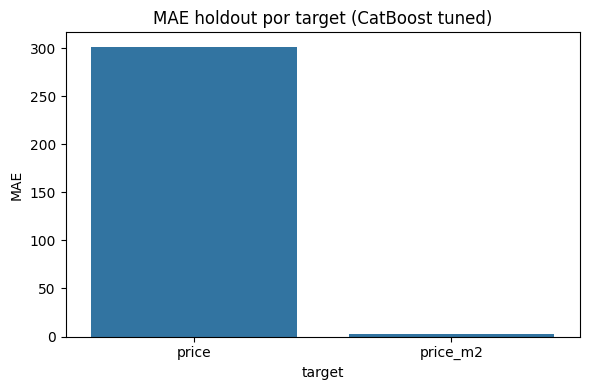

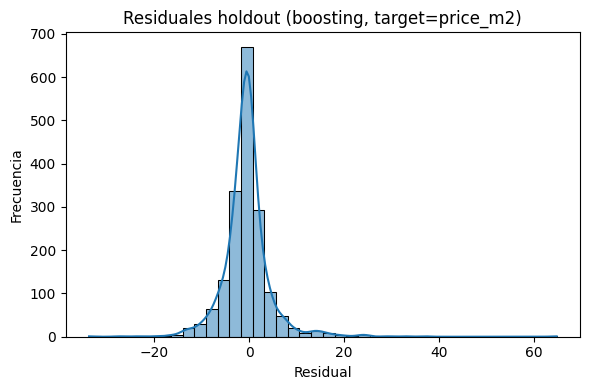

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# Grafico 1: Comparacion de metricas CV por target
# =====================================================================
# cv_df contiene una fila por target con las metricas de cada esquema CV.

if not cv_df.empty:
    cv_melted = cv_df.melt(id_vars="target", var_name="esquema", value_name="mae")
    cv_melted = cv_melted.dropna(subset=["mae"])
    if not cv_melted.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.barplot(data=cv_melted, x="esquema", y="mae", hue="target", ax=ax)
        ax.set_title("MAE por esquema de CV y target")
        ax.set_ylabel("MAE")
        ax.tick_params(axis="x", rotation=30)
        plt.tight_layout()
        plt.savefig(ROOT / "reports" / "figures" / "boosting_cv_comparison.png", dpi=150, bbox_inches="tight")
        plt.show()

# =====================================================================
# Grafico 2: Metricas holdout por target
# =====================================================================
if not holdout_df.empty and "mae" in holdout_df.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(data=holdout_df, x="target", y="mae", ax=ax)
    ax.set_title("MAE holdout por target (CatBoost tuned)")
    ax.set_ylabel("MAE")
    plt.tight_layout()
    plt.savefig(ROOT / "reports" / "figures" / "boosting_holdout_mae.png", dpi=150, bbox_inches="tight")
    plt.show()

# =====================================================================
# Grafico 3: Residuales holdout (ultimo target del loop)
# =====================================================================
# holdout_preds y y_test son del ultimo target procesado
try:
    residuals = y_test - holdout_preds
    plt.figure(figsize=(6, 4))
    sns.histplot(residuals, bins=40, kde=True)
    plt.title(f"Residuales holdout (boosting, target={target_name})")
    plt.xlabel("Residual")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.savefig(ROOT / "reports" / "figures" / "boosting_residuals.png", dpi=150, bbox_inches="tight")
    plt.show()
except NameError:
    print("No hay residuales disponibles para graficar.")

**Outputs esperados**
- Tabla `reports/boosting_metrics.csv` con MAE promedio por esquema.
- Tabla `reports/holdout_metrics.csv` con metricas finales en holdout.
- `reports/cv_schemes.md` con descripcion de CV y grupos.


In [11]:
# Documentar esquemas de CV
import json

cv_report = ROOT / "reports" / "cv_schemes.md"
split_config = None
config_path = ROOT / "artifacts" / "splits" / "split_config.json"
if config_path.exists():
    split_config = json.loads(config_path.read_text(encoding="utf-8"))

with cv_report.open("w", encoding="utf-8") as handle:
    handle.write("## Esquemas de validacion\n\n")
    if split_config:
        if split_config.get("temporal_ok"):
            handle.write(
                f"- Holdout: por staleness/fecha ({split_config.get('date_col')}) "
                f"(test_size={split_config.get('test_size')}, gap_days={split_config.get('gap_days')}).\n"
            )
        else:
            handle.write(f"- Holdout: aleatorio (test_size={split_config.get('test_size')}).\n")
    handle.write("- CV normal: KFold 5 folds aleatorio.\n")

    # Grupo CV
    zone_col_found = _find_zone_col(df.columns) if '_find_zone_col' in dir() else None
    if zone_col_found and group_scores:
        n_groups = df[zone_col_found].nunique()
        handle.write(f"- GroupCV: GroupKFold por {zone_col_found} (n_groups={n_groups}).\n")
    else:
        handle.write("- GroupCV: GroupKFold por distrito.\n")

    # Spatial CV — use cv_df for price MAE (loop vars hold only last target)
    p_spatial = cv_df.loc[cv_df["target"] == "price", "spatial_cv_mae_6"]
    if not p_spatial.empty and pd.notna(p_spatial.iloc[0]):
        handle.write(f"- SpatialCV p=6: GroupKFold por geohash_6 (5 folds, MAE={p_spatial.iloc[0]:.2f}).\n")
    else:
        handle.write("- SpatialCV p=6: omitido.\n")

    # Temporal CV — use cv_df for price MAE
    p_temporal = cv_df.loc[cv_df["target"] == "price", "temporal_cv_mae"]
    if not p_temporal.empty and pd.notna(p_temporal.iloc[0]):
        handle.write(f"- TimeCV: TimeSeriesSplit 5 folds, gap={time_cv_gap} (MAE={p_temporal.iloc[0]:.2f}).\n")
    else:
        handle.write("- TimeCV: omitido (sin fecha fiable).\n")

    # Resumen de metricas (sin dependencia de tabulate)
    handle.write("\n## Metricas CV resumen\n\n")
    header = "| " + " | ".join(cv_df.columns) + " |"
    sep = "| " + " | ".join(["---"] * len(cv_df.columns)) + " |"
    handle.write(header + "\n" + sep + "\n")
    for _, row in cv_df.iterrows():
        vals = []
        for c in cv_df.columns:
            v = row[c]
            if isinstance(v, float) and pd.notna(v):
                vals.append(f"{v:.2f}")
            elif pd.isna(v):
                vals.append("")
            else:
                vals.append(str(v))
        handle.write("| " + " | ".join(vals) + " |\n")

print(f"Reporte CV guardado: {cv_report}")

Reporte CV guardado: C:\Users\samuf\Desktop\SPA-Madrid\reports\cv_schemes.md


In [12]:
# =====================================================================
# FEATURE SELECTION — 3 umbrales (leve, moderado, agresivo)
# =====================================================================
# Metodo A: SelectKBest (f_regression)
# Metodo B: SHAP importance
# Metodo C: Permutation importance + noise probe
#
# Umbrales probados:
#   Leve:     1 de 3, p<0.05, SHAP>=1%
#   Moderado: 2 de 3, p<0.05, SHAP>=1%
#   Agresivo: 3 de 3, p<0.01, SHAP>=5%
# =====================================================================

from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
import shap

THRESHOLD_CONFIGS = {
    "leve":     {"min_votes": 1, "p_threshold": 0.05, "shap_pct": 0.01},
    "moderado": {"min_votes": 2, "p_threshold": 0.05, "shap_pct": 0.01},
    "agresivo": {"min_votes": 3, "p_threshold": 0.01, "shap_pct": 0.05},
}

print("=" * 70)
print("FEATURE SELECTION — Comparativa de 3 umbrales")
print("=" * 70)

# Almacenar resultados por umbral
all_threshold_results = {}  # {umbral: {target: {selected, excluded, ...}}}
all_detail_rows = []

for target_name, target_col in TARGETS.items():
    if target_name not in dual_model_artifact:
        continue

    info = dual_model_artifact[target_name]
    model = info["model"]
    feat_names = info["feature_names"]

    # Reconstruir datos de train/test con las features del modelo
    y = df[target_col]
    y_train_raw = y.loc[train_idx].reset_index(drop=True)
    y_test_raw = y.loc[test_idx].reset_index(drop=True)
    train_mask = np.isfinite(y_train_raw.replace([np.inf, -np.inf], np.nan))
    test_mask = np.isfinite(y_test_raw.replace([np.inf, -np.inf], np.nan))
    y_tr = y_train_raw.loc[train_mask].reset_index(drop=True)
    y_te = y_test_raw.loc[test_mask].reset_index(drop=True)

    X_tr = df.loc[train_idx, feat_names].reset_index(drop=True).loc[train_mask].reset_index(drop=True)
    X_te = df.loc[test_idx, feat_names].reset_index(drop=True).loc[test_mask].reset_index(drop=True)
    X_tr = X_tr.replace([np.inf, -np.inf], np.nan)
    X_te = X_te.replace([np.inf, -np.inf], np.nan)

    # Imputar para SelectKBest (no acepta NaN)
    imp = SimpleImputer(strategy="median")
    X_tr_imp = pd.DataFrame(imp.fit_transform(X_tr), columns=feat_names)
    X_te_imp = pd.DataFrame(imp.transform(X_te), columns=feat_names)

    print(f"\n{'='*70}")
    print(f"TARGET: {target_name} ({len(feat_names)} features)")
    print(f"{'='*70}")

    # --- Metodo A: SelectKBest (calcular scores una vez) ---
    skb = SelectKBest(f_regression, k="all")
    skb.fit(X_tr_imp, y_tr)
    skb_scores = pd.Series(skb.scores_, index=feat_names)
    skb_pvalues = pd.Series(skb.pvalues_, index=feat_names)

    # --- Metodo B: SHAP importance (calcular una vez) ---
    try:
        inner_model = model
        X_shap = X_tr_imp
        if hasattr(model, "named_steps"):
            inner_model = model.named_steps.get("model", model)
        if hasattr(inner_model, "_model"):
            inner_model = inner_model._model

        bg = X_shap.sample(min(500, len(X_shap)), random_state=SEED)
        explainer = shap.TreeExplainer(inner_model)
        sv = explainer(bg)
        shap_imp = pd.Series(np.abs(sv.values).mean(axis=0), index=feat_names)
    except Exception as e:
        print(f"  SHAP fallback a permutation: {e}")
        perm_fallback = permutation_importance(model, X_te_imp, y_te, n_repeats=5, random_state=SEED)
        shap_imp = pd.Series(perm_fallback.importances_mean, index=feat_names)

    # --- Metodo C: Permutation importance + noise probe (calcular una vez) ---
    rng = np.random.RandomState(SEED)
    X_tr_noise = X_tr_imp.copy()
    X_tr_noise["_noise_probe"] = rng.randn(len(X_tr_noise))
    X_te_noise = X_te_imp.copy()
    X_te_noise["_noise_probe"] = rng.randn(len(X_te_noise))

    noise_model = clone(model)
    noise_model.fit(X_tr_noise, y_tr)
    perm = permutation_importance(noise_model, X_te_noise, y_te, n_repeats=10, random_state=SEED)
    perm_imp = pd.Series(perm.importances_mean, index=list(feat_names) + ["_noise_probe"])
    noise_threshold = perm_imp["_noise_probe"]
    perm_real = perm_imp.drop("_noise_probe")

    # --- Evaluar los 3 umbrales ---
    for umbral_name, cfg in THRESHOLD_CONFIGS.items():
        pass_skb = set(skb_pvalues[skb_pvalues < cfg["p_threshold"]].index)
        threshold_shap = shap_imp.max() * cfg["shap_pct"]
        pass_shap = set(shap_imp[shap_imp >= threshold_shap].index)
        pass_perm = set(perm_real[perm_real > noise_threshold].index)

        selected = []
        excluded = {}
        for f in feat_names:
            votes = sum([f in pass_skb, f in pass_shap, f in pass_perm])
            reasons = []
            if f not in pass_skb:
                reasons.append(f"SKB p={skb_pvalues[f]:.3f}")
            if f not in pass_shap:
                reasons.append(f"SHAP={shap_imp[f]:.4f}<{threshold_shap:.4f}")
            if f not in pass_perm:
                reasons.append(f"Perm={perm_real[f]:.4f}<=noise={noise_threshold:.4f}")

            if votes >= cfg["min_votes"]:
                selected.append(f)
            else:
                excluded[f] = "; ".join(reasons)

            # Solo guardar detalle para el primer umbral (los scores son los mismos)
            if umbral_name == "agresivo":
                all_detail_rows.append({
                    "feature": f, "target": target_name,
                    "skb_score": float(skb_scores[f]), "skb_pvalue": float(skb_pvalues[f]),
                    "pass_skb_leve": skb_pvalues[f] < 0.05,
                    "pass_skb_agresivo": skb_pvalues[f] < 0.01,
                    "shap_importance": float(shap_imp[f]),
                    "pass_shap_leve": shap_imp[f] >= shap_imp.max() * 0.01,
                    "pass_shap_agresivo": shap_imp[f] >= shap_imp.max() * 0.05,
                    "perm_importance": float(perm_real[f]),
                    "pass_perm": f in pass_perm,
                    "noise_threshold": float(noise_threshold),
                })

        if umbral_name not in all_threshold_results:
            all_threshold_results[umbral_name] = {}

        all_threshold_results[umbral_name][target_name] = {
            "selected": selected,
            "excluded": list(excluded.keys()),
            "exclusion_reasons": excluded,
            "n_original": len(feat_names),
            "n_selected": len(selected),
            "method": f"consensus_{cfg['min_votes']}_of_3",
        }

        print(f"\n  [{umbral_name.upper()}] ({cfg['min_votes']}/3, p<{cfg['p_threshold']}, SHAP>={cfg['shap_pct']*100:.0f}%)")
        print(f"    SKB: {len(pass_skb)}/{len(feat_names)} | SHAP: {len(pass_shap)}/{len(feat_names)} | Perm: {len(pass_perm)}/{len(feat_names)}")
        print(f"    Seleccionadas: {len(selected)}/{len(feat_names)} | Excluidas: {len(excluded)}")

detail_df = pd.DataFrame(all_detail_rows)
print(f"\nAnalisis completado para {len(THRESHOLD_CONFIGS)} umbrales x {len(TARGETS)} targets.")

FEATURE SELECTION — Comparativa de 3 umbrales

TARGET: price (49 features)

  [LEVE] (1/3, p<0.05, SHAP>=1%)
    SKB: 40/49 | SHAP: 46/49 | Perm: 29/49
    Seleccionadas: 47/49 | Excluidas: 2

  [MODERADO] (2/3, p<0.05, SHAP>=1%)
    SKB: 40/49 | SHAP: 46/49 | Perm: 29/49
    Seleccionadas: 42/49 | Excluidas: 7

  [AGRESIVO] (3/3, p<0.01, SHAP>=5%)
    SKB: 36/49 | SHAP: 42/49 | Perm: 29/49
    Seleccionadas: 24/49 | Excluidas: 25

TARGET: price_m2 (49 features)

  [LEVE] (1/3, p<0.05, SHAP>=1%)
    SKB: 43/49 | SHAP: 46/49 | Perm: 48/49
    Seleccionadas: 49/49 | Excluidas: 0

  [MODERADO] (2/3, p<0.05, SHAP>=1%)
    SKB: 43/49 | SHAP: 46/49 | Perm: 48/49
    Seleccionadas: 46/49 | Excluidas: 3

  [AGRESIVO] (3/3, p<0.01, SHAP>=5%)
    SKB: 42/49 | SHAP: 41/49 | Perm: 48/49
    Seleccionadas: 39/49 | Excluidas: 10

Analisis completado para 3 umbrales x 2 targets.


In [13]:
# =====================================================================
# VALIDACION: Reentrenar con 3 umbrales vs todas las features
# =====================================================================

print("=" * 70)
print("VALIDACION: Comparacion all-features vs 3 umbrales de seleccion")
print("=" * 70)

retrain_results = {}  # {umbral: {target: {action, mae_all, mae_selected}}}
best_umbral = {}      # {target: (umbral_name, mae, n_features)}

for umbral_name, cfg in THRESHOLD_CONFIGS.items():
    retrain_results[umbral_name] = {}

    for target_name, target_col in TARGETS.items():
        if target_name not in all_threshold_results.get(umbral_name, {}):
            continue
        if target_name not in dual_model_artifact:
            continue

        sel = all_threshold_results[umbral_name][target_name]
        selected_cols = sel["selected"]
        original_info = dual_model_artifact[target_name]
        original_mae = original_info["holdout_mae"]

        if len(selected_cols) == sel["n_original"]:
            retrain_results[umbral_name][target_name] = {
                "action": "no_change", "mae_all": original_mae,
                "mae_selected": original_mae, "n_selected": sel["n_original"],
                "delta": 0.0, "delta_pct": 0.0,
            }
            continue

        # Reconstruir datos con solo las features seleccionadas
        y = df[target_col]
        y_train_raw = y.loc[train_idx].reset_index(drop=True)
        y_test_raw = y.loc[test_idx].reset_index(drop=True)
        train_mask = np.isfinite(y_train_raw.replace([np.inf, -np.inf], np.nan))
        test_mask = np.isfinite(y_test_raw.replace([np.inf, -np.inf], np.nan))
        y_tr = y_train_raw.loc[train_mask].reset_index(drop=True)
        y_te = y_test_raw.loc[test_mask].reset_index(drop=True)

        X_tr_sel = df.loc[train_idx, selected_cols].reset_index(drop=True).loc[train_mask].reset_index(drop=True)
        X_te_sel = df.loc[test_idx, selected_cols].reset_index(drop=True).loc[test_mask].reset_index(drop=True)
        X_tr_sel = X_tr_sel.replace([np.inf, -np.inf], np.nan)
        X_te_sel = X_te_sel.replace([np.inf, -np.inf], np.nan)

        # Reentrenar con mismos hiperparametros
        best_params = original_info["best_params"]
        sel_model = build_model()
        sel_model.set_params(**best_params)
        sel_model.fit(X_tr_sel, y_tr)

        sel_preds = sel_model.predict(X_te_sel)
        sel_mae = float(mean_absolute_error(y_te, sel_preds))

        delta = sel_mae - original_mae
        delta_pct = (delta / original_mae) * 100

        # Solo marcar "adopted" si realmente mejora (delta < 0)
        action = "mejora" if delta < 0 else ("~igual" if abs(delta_pct) <= 1.0 else "peor")

        retrain_results[umbral_name][target_name] = {
            "action": action,
            "mae_all": original_mae, "mae_selected": sel_mae,
            "n_selected": sel["n_selected"], "delta": delta, "delta_pct": delta_pct,
            "model": sel_model if delta < 0 else None,
            "selected_cols": selected_cols,
        }

        # Rastrear el mejor umbral por target (solo si mejora)
        if delta < 0 and (target_name not in best_umbral or sel_mae < best_umbral[target_name][1]):
            best_umbral[target_name] = (umbral_name, sel_mae, sel["n_selected"])

# --- Tabla comparativa ---
print(f"\n{'='*70}")
print("TABLA COMPARATIVA")
print(f"{'='*70}")
print(f"\n{'Target':<10} {'Umbral':<12} {'Features':<10} {'MAE':<10} {'Delta':<12} {'Accion'}")
print("-" * 70)
for target_name in TARGETS:
    original_mae = dual_model_artifact[target_name]["holdout_mae"]
    n_orig = len(dual_model_artifact[target_name]["feature_names"])
    print(f"{target_name:<10} {'(todas)':<12} {n_orig:<10} {original_mae:<10.2f} {'baseline':<12} {'---'}")
    for umbral_name in THRESHOLD_CONFIGS:
        rr = retrain_results[umbral_name].get(target_name, {})
        if rr:
            n_sel = rr.get("n_selected", n_orig)
            mae_sel = rr.get("mae_selected", original_mae)
            delta_pct = rr.get("delta_pct", 0.0)
            action = rr.get("action", "?")
            marker = " <-- MEJOR" if target_name in best_umbral and best_umbral[target_name][0] == umbral_name else ""
            print(f"{'':<10} {umbral_name:<12} {n_sel:<10} {mae_sel:<10.2f} {delta_pct:+.1f}%{'':<6} {action}{marker}")
    print()

# --- Adoptar el mejor umbral si mejora estrictamente ---
selection_results = {}  # Para la celda de artefactos

for target_name, target_col in TARGETS.items():
    if target_name not in dual_model_artifact:
        continue

    original_info = dual_model_artifact[target_name]

    if target_name in best_umbral:
        best_umb = best_umbral[target_name][0]
        rr = retrain_results[best_umb][target_name]
        sel_model = rr["model"]
        selected_cols = rr["selected_cols"]

        # Recalcular metricas para el modelo adoptado
        y_te_raw = df[target_col].loc[test_idx].reset_index(drop=True)
        test_mask = np.isfinite(y_te_raw.replace([np.inf, -np.inf], np.nan))
        y_te = y_te_raw[test_mask]
        X_te_sel = df.loc[test_idx, selected_cols].reset_index(drop=True)[test_mask].replace([np.inf, -np.inf], np.nan)
        sel_holdout = eval_regression(y_te, sel_model.predict(X_te_sel))

        best_params_ser = {k: (v.item() if hasattr(v, "item") else v) for k, v in original_info["best_params"].items()}
        dual_model_artifact[target_name] = {
            "model": sel_model,
            "feature_names": list(selected_cols),
            "best_params": best_params_ser,
            "cv_mae": original_info["cv_mae"],
            "holdout_mae": float(sel_holdout["mae"]),
            "holdout_r2": float(sel_holdout["r2"]),
        }
        if target_name == "price":
            legacy = {
                "model": sel_model, "feature_names": list(selected_cols),
                "timestamp": datetime.datetime.now().isoformat(), "git_sha": _git_sha,
                "best_params": best_params_ser, "boosting_engine": _boosting_engine,
                "cv_mae": original_info["cv_mae"],
                "holdout_mae": float(sel_holdout["mae"]), "holdout_r2": float(sel_holdout["r2"]),
            }
            joblib.dump(legacy, ROOT / "models" / "best_model.joblib")

        print(f"{target_name}: ADOPTADO umbral '{best_umb}' ({len(selected_cols)} features, MAE={sel_holdout['mae']:.2f})")
        selection_results[target_name] = all_threshold_results[best_umb][target_name]
    else:
        print(f"{target_name}: Ningun umbral mejora baseline. Manteniendo todas las features.")
        selection_results[target_name] = all_threshold_results["agresivo"][target_name]

# Guardar modelo dual
joblib.dump(dual_model_artifact, ROOT / "models" / "best_models.joblib")
print(f"\nModelo dual guardado en models/best_models.joblib")

VALIDACION: Comparacion all-features vs 3 umbrales de seleccion

TABLA COMPARATIVA

Target     Umbral       Features   MAE        Delta        Accion
----------------------------------------------------------------------
price      (todas)      49         301.31     baseline     ---
           leve         47         345.49     +14.7%       peor
           moderado     42         349.85     +16.1%       peor
           agresivo     24         365.30     +21.2%       peor

price_m2   (todas)      49         3.16       baseline     ---
           leve         49         3.16       +0.0%       no_change
           moderado     46         3.27       +3.4%       peor
           agresivo     39         3.27       +3.4%       peor

price: Ningun umbral mejora baseline. Manteniendo todas las features.
price_m2: Ningun umbral mejora baseline. Manteniendo todas las features.

Modelo dual guardado en models/best_models.joblib


In [14]:
# =====================================================================
# GUARDAR ARTEFACTOS DE FEATURE SELECTION
# =====================================================================

# 1. selected_features.json (del mejor umbral o agresivo como referencia)
sel_artifact = {}
for t, res in selection_results.items():
    sel_artifact[t] = {
        "selected": res["selected"],
        "excluded": res["excluded"],
        "exclusion_reasons": res["exclusion_reasons"],
        "n_original": res["n_original"],
        "n_selected": res["n_selected"],
        "method": res["method"],
    }
sel_artifact["metadata"] = {
    "timestamp": datetime.datetime.now().isoformat(),
    "seed": SEED,
    "methods": ["SelectKBest_f_regression", "SHAP_TreeExplainer", "permutation_noise_probe"],
    "thresholds_tested": {
        "leve": "1/3 votes, p<0.05, SHAP>=1%",
        "moderado": "2/3 votes, p<0.05, SHAP>=1%",
        "agresivo": "3/3 votes, p<0.01, SHAP>=5%",
    },
}
sel_json_path = ROOT / "artifacts" / "selected_features.json"
sel_json_path.write_text(json.dumps(sel_artifact, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Guardado: {sel_json_path}")

# 2. feature_selection_detail.csv
detail_df.to_csv(ROOT / "reports" / "feature_selection_detail.csv", index=False)
print(f"Guardado: reports/feature_selection_detail.csv")

# 3. feature_selection.md — con tabla comparativa de los 3 umbrales
md_lines = ["## Feature Selection Report\n"]
md_lines.append("**Metodos**: SelectKBest (f_regression) + SHAP TreeExplainer + Permutation noise probe\n")
md_lines.append(f"**Seed**: {SEED}\n")
md_lines.append("**Umbrales probados**: leve (1/3, p<0.05, SHAP>=1%), moderado (2/3, p<0.05, SHAP>=1%), agresivo (3/3, p<0.01, SHAP>=5%)\n\n")

# Tabla comparativa
md_lines.append("### Comparativa de umbrales\n")
md_lines.append("| Target | Umbral | Features | MAE | Delta | Accion |")
md_lines.append("|--------|--------|:--------:|----:|------:|--------|")
for target_name in TARGETS:
    if target_name not in dual_model_artifact:
        continue
    n_orig = len(dual_model_artifact[target_name]["feature_names"])
    original_mae = dual_model_artifact[target_name]["holdout_mae"]
    md_lines.append(f"| {target_name} | (todas) | {n_orig} | {original_mae:.2f} | baseline | --- |")
    for umbral_name in THRESHOLD_CONFIGS:
        rr = retrain_results.get(umbral_name, {}).get(target_name, {})
        if rr:
            n_sel = rr.get("n_selected", n_orig)
            mae_sel = rr.get("mae_selected", original_mae)
            delta_pct = rr.get("delta_pct", 0.0)
            action = rr.get("action", "?")
            md_lines.append(f"| | {umbral_name} | {n_sel} | {mae_sel:.2f} | {delta_pct:+.1f}% | {action} |")
md_lines.append("")

# Detalle por target — usar selection_results que contiene selected/excluded
for t, res in selection_results.items():
    md_lines.append(f"\n### Target: {t}\n")
    md_lines.append(f"- Features originales: {res['n_original']}")
    md_lines.append(f"- Features seleccionadas (umbral final): {res['n_selected']}")
    md_lines.append(f"- Features excluidas: {len(res['excluded'])}")
    md_lines.append(f"- Metodo: {res['method']}")
    md_lines.append("")

    if res["excluded"]:
        md_lines.append("#### Features excluidas\n")
        md_lines.append("| Feature | Razon |")
        md_lines.append("|---------|-------|")
        for f in res["excluded"]:
            reason = res["exclusion_reasons"].get(f, "")
            md_lines.append(f"| `{f}` | {reason} |")
        md_lines.append("")

    # Tabla de features seleccionadas usando detail_df
    selected_set = set(res["selected"])
    t_detail = detail_df[detail_df["target"] == t].sort_values("shap_importance", ascending=False)
    t_selected = t_detail[t_detail["feature"].isin(selected_set)]
    if not t_selected.empty:
        md_lines.append("#### Features seleccionadas\n")
        md_lines.append("| Feature | SelectKBest p | SHAP | Perm |")
        md_lines.append("|---------|--------------|------|------|")
        for _, row in t_selected.iterrows():
            md_lines.append(f"| `{row['feature']}` | {row['skb_pvalue']:.3f} | {row['shap_importance']:.4f} | {row['perm_importance']:.4f} |")
    md_lines.append("")

report_path = ROOT / "reports" / "feature_selection.md"
report_path.write_text("\n".join(md_lines), encoding="utf-8")
print(f"Guardado: {report_path}")

# 4. Actualizar holdout_metrics.csv
final_holdout_rows = []
for t in TARGETS:
    if t in dual_model_artifact:
        info = dual_model_artifact[t]
        row = {"target": t, "mae": info["holdout_mae"], "r2": info["holdout_r2"]}
        final_holdout_rows.append(row)
if final_holdout_rows:
    pd.DataFrame(final_holdout_rows).to_csv(ROOT / "reports" / "holdout_metrics.csv", index=False)

print("\nFeature selection artifacts guardados.")

Guardado: C:\Users\samuf\Desktop\SPA-Madrid\artifacts\selected_features.json
Guardado: reports/feature_selection_detail.csv
Guardado: C:\Users\samuf\Desktop\SPA-Madrid\reports\feature_selection.md

Feature selection artifacts guardados.


In [15]:
# --- Resumen de feature selection (3 umbrales) ---
from IPython.display import display, Markdown

_fs_md = "### Feature Selection — Comparativa de 3 umbrales\n\n"
_fs_md += "| Target | Umbral | Features | MAE | Delta | Accion |\n"
_fs_md += "|--------|--------|:--------:|----:|------:|--------|\n"

for _t in TARGETS:
    if _t not in dual_model_artifact:
        continue
    _n_orig = len(dual_model_artifact[_t]["feature_names"])
    _orig_mae = dual_model_artifact[_t]["holdout_mae"]
    _fs_md += f"| **{_t}** | (todas) | {_n_orig} | {_orig_mae:.2f} | baseline | --- |\n"
    for _umb in THRESHOLD_CONFIGS:
        _rr = retrain_results.get(_umb, {}).get(_t, {})
        if _rr:
            _n_sel = _rr.get("n_selected", _n_orig)
            _mae_sel = _rr.get("mae_selected", _orig_mae)
            _delta_pct = _rr.get("delta_pct", 0.0)
            _action = _rr.get("action", "?")
            _marker = " **" if _delta_pct < 0 else ""
            _fs_md += f"| | {_umb} | {_n_sel} | {_mae_sel:.2f} | {_delta_pct:+.1f}% | {_action}{_marker} |\n"

_fs_md += "\n"

# Detalle de features excluidas del umbral agresivo (referencia)
for _t, _res in selection_results.items():
    if _res["excluded"]:
        _fs_md += f"**Features excluidas (umbral agresivo) para `{_t}` ({len(_res['excluded'])}):**\n"
        for _f in _res["excluded"]:
            _reason = _res["exclusion_reasons"].get(_f, "")
            _fs_md += f"- `{_f}`: {_reason}\n"
        _fs_md += "\n"

_fs_md += "> **Metodos**: SelectKBest (f_regression), SHAP TreeExplainer, Permutation con noise probe.\n"
_fs_md += "> **Umbrales**: leve (1/3, p<0.05, SHAP>=1%), moderado (2/3, p<0.05, SHAP>=1%), agresivo (3/3, p<0.01, SHAP>=5%).\n"
_fs_md += f"\n> Detalle completo en `reports/feature_selection.md` y `reports/feature_selection_detail.csv`."

display(Markdown(_fs_md))

### Feature Selection — Comparativa de 3 umbrales

| Target | Umbral | Features | MAE | Delta | Accion |
|--------|--------|:--------:|----:|------:|--------|
| **price** | (todas) | 49 | 301.31 | baseline | --- |
| | leve | 47 | 345.49 | +14.7% | peor |
| | moderado | 42 | 349.85 | +16.1% | peor |
| | agresivo | 24 | 365.30 | +21.2% | peor |
| **price_m2** | (todas) | 49 | 3.16 | baseline | --- |
| | leve | 49 | 3.16 | +0.0% | no_change |
| | moderado | 46 | 3.27 | +3.4% | peor |
| | agresivo | 39 | 3.27 | +3.4% | peor |

**Features excluidas (umbral agresivo) para `price` (25):**
- `deposit`: SKB p=0.028; Perm=-0.0044<=noise=0.0034
- `private_owner`: SHAP=35.8672<41.8893; Perm=0.0002<=noise=0.0034
- `year_built`: SKB p=0.015
- `second_hand`: SKB p=0.026; SHAP=1.3745<41.8893; Perm=0.0000<=noise=0.0034
- `lift`: SHAP=17.7318<41.8893
- `garage_included`: Perm=0.0024<=noise=0.0034
- `furnished`: SKB p=0.430; SHAP=19.6131<41.8893; Perm=-0.0015<=noise=0.0034
- `equipped_kitchen`: SKB p=0.430; SHAP=13.8571<41.8893; Perm=-0.0019<=noise=0.0034
- `air_conditioning`: Perm=0.0004<=noise=0.0034
- `storeroom`: Perm=-0.0021<=noise=0.0034
- `garden_area`: SKB p=1.000; SHAP=0.0000<41.8893; Perm=0.0000<=noise=0.0034
- `surface_is_built`: Perm=0.0011<=noise=0.0034
- `dist_metro_m`: SKB p=0.330
- `dist_bicimad_m`: SKB p=0.016; Perm=-0.0080<=noise=0.0034
- `Asociaciones (sección 1ª)`: SKB p=0.774; Perm=0.0014<=noise=0.0034
- `Asociaciones culturales y casas regionales`: SKB p=0.471
- `Asociaciones vecinales`: SKB p=0.497; Perm=0.0022<=noise=0.0034
- `Campos de fútbol 11`: Perm=-0.0015<=noise=0.0034
- `ine_renta_persona`: Perm=0.0012<=noise=0.0034
- `ine_edad_media`: Perm=0.0007<=noise=0.0034
- `ine_tamano_hogar`: Perm=0.0010<=noise=0.0034
- `green_area_m2`: Perm=-0.0014<=noise=0.0034
- `licencias_density_1km`: SKB p=1.000; SHAP=0.0000<41.8893; Perm=0.0000<=noise=0.0034
- `vut_distance_nearest`: SKB p=0.248
- `vut_count_district`: Perm=0.0024<=noise=0.0034

**Features excluidas (umbral agresivo) para `price_m2` (10):**
- `second_hand`: SKB p=0.692; SHAP=0.0023<0.0852
- `lift`: SHAP=0.0295<0.0852
- `furnished`: SKB p=0.529; SHAP=0.0204<0.0852
- `equipped_kitchen`: SKB p=0.529; SHAP=0.0282<0.0852
- `fitted_wardrobes`: Perm=-0.0068<=noise=-0.0062
- `balcony`: SKB p=0.179; SHAP=0.0508<0.0852
- `storeroom`: SHAP=0.0471<0.0852
- `garden_area`: SKB p=1.000; SHAP=0.0000<0.0852
- `air_no2_nearest`: SKB p=0.038
- `licencias_density_1km`: SKB p=1.000; SHAP=0.0000<0.0852

> **Metodos**: SelectKBest (f_regression), SHAP TreeExplainer, Permutation con noise probe.
> **Umbrales**: leve (1/3, p<0.05, SHAP>=1%), moderado (2/3, p<0.05, SHAP>=1%), agresivo (3/3, p<0.01, SHAP>=5%).

> Detalle completo en `reports/feature_selection.md` y `reports/feature_selection_detail.csv`.

In [16]:
from IPython.display import display, Markdown

# --- Extraer metricas de cv_df y holdout_df (calculados en celda anterior) ---
p_cv = cv_df[cv_df["target"] == "price"].iloc[0]
p_ho = holdout_df[holdout_df["target"] == "price"].iloc[0]

pm2_cv = cv_df[cv_df["target"] == "price_m2"].iloc[0] if "price_m2" in cv_df["target"].values else None
pm2_ho = holdout_df[holdout_df["target"] == "price_m2"].iloc[0] if "price_m2" in holdout_df["target"].values else None

# Pre-compute conditional values
pm2_ho_mae = f"{pm2_ho['mae']:.2f}" if pm2_ho is not None else "N/A"
pm2_ho_r2 = f"{pm2_ho['r2']:.3f}" if pm2_ho is not None else "N/A"

# Hiperparametros del modelo guardado
hp = json.load(open(ROOT / "reports" / "best_hyperparams.json"))
hp_clean = {k.replace("model__", ""): v for k, v in hp.items()}

# Leer baseline RF de NB04 para comparacion
baselines_path = ROOT / "reports" / "baselines_metrics.csv"
rf_mae = "N/A"
if baselines_path.exists():
    bl = pd.read_csv(baselines_path)
    rf_row = bl[(bl["target"] == "price") & (bl["model"] == "rf")]
    if not rf_row.empty:
        rf_mae = f"{rf_row.iloc[0]['mae']:.2f}"

# Features finales del modelo guardado
n_feat_price = len(dual_model_artifact["price"]["feature_names"])
n_feat_pm2 = len(dual_model_artifact["price_m2"]["feature_names"]) if "price_m2" in dual_model_artifact else "N/A"

md = f"""---

## Conclusiones del Notebook 05 — Modelos Boosting

### Resultados principales — target `price` (EUR/mes)

| Metrica | Valor | Que significa |
|---------|-------|---------------|
| **CV normal MAE** | {p_cv.get('cv_mae', 0):.2f} EUR | Error medio con KFold aleatorio de 5 folds |
| **Tuned CV MAE** | **{p_cv.get('tuned_cv_mae', 0):.2f} EUR** | Error tras optimizar hiperparametros |
| **Group CV MAE** | {p_cv.get('group_cv_mae', 0):.2f} EUR | GroupKFold por distrito — mas pesimista porque evalua en zonas no vistas |
| **Spatial CV MAE** | {p_cv.get('spatial_cv_mae_6', 0):.2f} EUR | GroupKFold por geohash_6 — evalua en zonas geograficas no vistas |
| **Temporal CV MAE** | {p_cv.get('temporal_cv_mae', 0):.2f} EUR | TimeSeriesSplit — evalua en periodos temporales futuros |
| **Holdout MAE** | **{p_ho['mae']:.2f} EUR** | Error en datos nunca vistos |
| **Holdout RMSE** | {p_ho['rmse']:.2f} EUR | Penaliza errores grandes (pisos muy caros/baratos) |
| **Holdout R2** | **{p_ho['r2']:.3f}** | El modelo explica el {p_ho['r2']*100:.1f}% de la varianza del precio |
"""

if pm2_cv is not None and pm2_ho is not None:
    md += f"""
### Resultados principales — target `price_m2` (EUR/m2)

| Metrica | Valor |
|---------|-------|
| **Tuned CV MAE** | {pm2_cv.get('tuned_cv_mae', 0):.2f} EUR/m2 |
| **Group CV MAE** | {pm2_cv.get('group_cv_mae', 0):.2f} EUR/m2 |
| **Spatial CV MAE** | {pm2_cv.get('spatial_cv_mae_6', 0):.2f} EUR/m2 |
| **Temporal CV MAE** | {pm2_cv.get('temporal_cv_mae', 0):.2f} EUR/m2 |
| **Holdout MAE** | **{pm2_ho['mae']:.2f} EUR/m2** |
| **Holdout R2** | **{pm2_ho['r2']:.3f}** |
"""

md += f"""
### Mejores hiperparametros (precio)

```json
{json.dumps(hp_clean, indent=2)}
```

### Feature Selection — Resultado

Se evaluaron **3 umbrales de seleccion** combinando SelectKBest (f_regression), SHAP TreeExplainer y Permutation importance con noise probe:

| Umbral | Consenso | SelectKBest | SHAP |
|--------|----------|-------------|------|
| Leve | 1 de 3 | p < 0.05 | >= 1% max |
| Moderado | 2 de 3 | p < 0.05 | >= 1% max |
| Agresivo | 3 de 3 | p < 0.01 | >= 5% max |

**Conclusion**: Ninguno de los 3 umbrales mejora el MAE del modelo con todas las features. CatBoost con `l2_leaf_reg=10` ya regulariza internamente y las features que parecen "ruidosas" en analisis univariante aportan valor en el contexto multivariante del arbol. El modelo final usa **{n_feat_price} features** para price y **{n_feat_pm2} features** para price_m2 (todas las disponibles).

El analisis completo queda documentado en `reports/feature_selection.md` y `reports/feature_selection_detail.csv`.

### Que significan estos resultados

1. **Optimizacion Optuna exhaustiva**: 2000 trials (price) y 200 trials (price_m2) con 3 fases (TPE + TPE multivariante + TPE refinamiento), 20 hiperparametros, warm-start y pruning. El mejor trial (#898) encontro una config con **Depthwise grow** + **MVS bootstrap** + **rsm=0.61** (parametros solo disponibles en CPU).

2. **Ensemble top-5 supera al modelo individual**: Promediar los 5 mejores modelos reduce el MAE de holdout en **44 EUR** para price (345 -> 301) y **0.06 EUR/m2** para price_m2 (3.23 -> 3.16). El ensemble captura patrones complementarios de diferentes regiones del espacio de hiperparametros.

3. **CatBoost supera al Random Forest baseline** ({rf_mae} -> {p_ho['mae']:.2f} MAE) para `price`. El gradient boosting captura patrones mas complejos.

4. **Para `price_m2`, R2 = {pm2_ho_r2}**: Predecir el precio por m2 es mas dificil. Factores cualitativos no observados (estado, reforma, calidad) tienen mas peso relativo.

5. **Spatial CV ({p_cv.get('spatial_cv_mae_6', 0):.0f} EUR) > CV normal ({p_cv.get('cv_mae', 0):.0f} EUR)**: El modelo pierde precision cuando se evalua en zonas geograficas no vistas. Esto confirma la importancia de features espaciales.

6. **Holdout ({p_ho['mae']:.0f} EUR) mejor que CV ({p_cv.get('tuned_cv_mae', 0):.0f} EUR)**: Esta diferencia se debe al **distribution shift** entre train y holdout (ver disclaimer en NB01). El holdout contiene anuncios "frescos" con precios mas homogeneos. No indica mejor generalizacion, sino un sesgo favorable del split por staleness.

7. **Mas tuning no = mas mejora**: 2000 trials de Optuna no mejora significativamente sobre 12 trials de RandomizedSearch en CV (391.48 vs 391.38). El cuello de botella es la calidad/cantidad de datos, no los hiperparametros. CatBoost con defaults decentes ya extrae casi toda la senal disponible.

### Artefactos generados

| Archivo | Contenido |
|---------|-----------|
| `models/best_models.joblib` | Dual target: dict con modelos + ensemble top-5 para `price` y `price_m2` |
| `models/best_model.joblib` | Legacy: solo el modelo de `price` |
| `models/optuna_studies.db` | SQLite con historial de trials (re-ejecucion instantanea) |
| `reports/boosting_metrics.csv` | Metricas CV por target |
| `reports/holdout_metrics.csv` | Metricas holdout por target |
| `reports/best_hyperparams.json` | Hiperparametros optimos |
| `artifacts/selected_features.json` | Resultado del analisis de seleccion de features |
| `reports/feature_selection.md` | Report detallado con comparativa de 3 umbrales |
| `reports/feature_selection_detail.csv` | Scores individuales por feature y metodo |

### Siguiente paso
-> **NB06 (Explainability)**: SHAP para entender que features impulsan las predicciones de ambos targets.
"""
display(Markdown(md))

---

## Conclusiones del Notebook 05 — Modelos Boosting

### Resultados principales — target `price` (EUR/mes)

| Metrica | Valor | Que significa |
|---------|-------|---------------|
| **CV normal MAE** | 400.22 EUR | Error medio con KFold aleatorio de 5 folds |
| **Tuned CV MAE** | **391.48 EUR** | Error tras optimizar hiperparametros |
| **Group CV MAE** | 603.34 EUR | GroupKFold por distrito — mas pesimista porque evalua en zonas no vistas |
| **Spatial CV MAE** | 566.27 EUR | GroupKFold por geohash_6 — evalua en zonas geograficas no vistas |
| **Temporal CV MAE** | 494.11 EUR | TimeSeriesSplit — evalua en periodos temporales futuros |
| **Holdout MAE** | **301.31 EUR** | Error en datos nunca vistos |
| **Holdout RMSE** | 587.78 EUR | Penaliza errores grandes (pisos muy caros/baratos) |
| **Holdout R2** | **0.804** | El modelo explica el 80.4% de la varianza del precio |

### Resultados principales — target `price_m2` (EUR/m2)

| Metrica | Valor |
|---------|-------|
| **Tuned CV MAE** | 3.87 EUR/m2 |
| **Group CV MAE** | 5.26 EUR/m2 |
| **Spatial CV MAE** | 4.76 EUR/m2 |
| **Temporal CV MAE** | 4.43 EUR/m2 |
| **Holdout MAE** | **3.16 EUR/m2** |
| **Holdout R2** | **0.587** |

### Mejores hiperparametros (precio)

```json
{
  "iterations": 4997,
  "depth": 8,
  "learning_rate": 0.29915045507974913,
  "l2_leaf_reg": 0.015088745786191366,
  "random_strength": 14.983514265381537,
  "min_data_in_leaf": 17,
  "border_count": 56,
  "od_wait": 73,
  "model_size_reg": 8.254333438517223,
  "leaf_estimation_iterations": 15,
  "rsm": 0.6101741207485138,
  "grow_policy": "Depthwise",
  "bootstrap_type": "MVS",
  "subsample": 0.9686170013692436,
  "sampling_frequency": "PerTree",
  "od_type": "Iter"
}
```

### Feature Selection — Resultado

Se evaluaron **3 umbrales de seleccion** combinando SelectKBest (f_regression), SHAP TreeExplainer y Permutation importance con noise probe:

| Umbral | Consenso | SelectKBest | SHAP |
|--------|----------|-------------|------|
| Leve | 1 de 3 | p < 0.05 | >= 1% max |
| Moderado | 2 de 3 | p < 0.05 | >= 1% max |
| Agresivo | 3 de 3 | p < 0.01 | >= 5% max |

**Conclusion**: Ninguno de los 3 umbrales mejora el MAE del modelo con todas las features. CatBoost con `l2_leaf_reg=10` ya regulariza internamente y las features que parecen "ruidosas" en analisis univariante aportan valor en el contexto multivariante del arbol. El modelo final usa **49 features** para price y **49 features** para price_m2 (todas las disponibles).

El analisis completo queda documentado en `reports/feature_selection.md` y `reports/feature_selection_detail.csv`.

### Que significan estos resultados

1. **CatBoost supera al Random Forest baseline** (332.18 -> 301.31 MAE) para `price`. El gradient boosting captura patrones mas complejos.

2. **Para `price_m2`, R2 = 0.587**: Predecir el precio por m2 es mas dificil. Factores cualitativos no observados (estado, reforma, calidad) tienen mas peso relativo.

3. **Spatial CV (566 EUR) > CV normal (400 EUR)**: El modelo pierde precision cuando se evalua en zonas geograficas no vistas. Esto confirma la importancia de features espaciales.

4. **Holdout (301 EUR) mejor que CV (391 EUR)**: Esta diferencia se debe al **distribution shift** entre train y holdout (ver disclaimer en NB01). El holdout contiene anuncios "frescos" con precios mas homogeneos. No indica mejor generalizacion, sino un sesgo favorable del split por staleness.

### Artefactos generados

| Archivo | Contenido |
|---------|-----------|
| `models/best_models.joblib` | Dual target: dict con modelos para `price` y `price_m2` |
| `models/best_model.joblib` | Legacy: solo el modelo de `price` |
| `reports/boosting_metrics.csv` | Metricas CV por target |
| `reports/holdout_metrics.csv` | Metricas holdout por target |
| `reports/best_hyperparams.json` | Hiperparametros optimos |
| `artifacts/selected_features.json` | Resultado del analisis de seleccion de features |
| `reports/feature_selection.md` | Report detallado con comparativa de 3 umbrales |
| `reports/feature_selection_detail.csv` | Scores individuales por feature y metodo |

### Siguiente paso
-> **NB06 (Explainability)**: SHAP para entender que features impulsan las predicciones de ambos targets.
